# 01 - Exploratory Data Analysis
## Metro Train Air Compressor - Failure Prediction

This notebook covers:
- Data loading and initial inspection
- Understanding sensor signals
- Visualizing time series data
- Identifying failure periods
- Correlation analysis

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Load Data

In [2]:
# Load the dataset
DATA_PATH = '../dataset/metropt+3+dataset/MetroPT3(AirCompressor).csv'

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset shape: (1516948, 17)
Memory usage: 295.12 MB


In [3]:
# First look at the data
df.head(10)

,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
5,50,2020-02-01 00:00:49,-0.012,9.306,9.290,-0.024,9.308,53.500,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
6,60,2020-02-01 00:00:59,-0.012,9.296,9.280,-0.024,9.298,53.375,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
7,70,2020-02-01 00:01:09,-0.014,9.286,9.270,-0.024,9.286,53.550,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
8,80,2020-02-01 00:01:19,-0.012,9.276,9.258,-0.022,9.276,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
9,90,2020-02-01 00:01:29,-0.012,9.264,9.248,-0.022,9.264,53.375,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


In [4]:
# Data types and info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1516948 entries, 0 to 1516947
Data columns (total 17 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   Unnamed: 0       1516948 non-null  int64  
 1   timestamp        1516948 non-null  object 
 2   TP2              1516948 non-null  float64
 3   TP3              1516948 non-null  float64
 4   H1               1516948 non-null  float64
 5   DV_pressure      1516948 non-null  float64
 6   Reservoirs       1516948 non-null  float64
 7   Oil_temperature  1516948 non-null  float64
 8   Motor_current    1516948 non-null  float64
 9   COMP             1516948 non-null  float64
 10  DV_eletric       1516948 non-null  float64
 11  Towers           1516948 non-null  float64
 12  MPG              1516948 non-null  float64
 13  LPS              1516948 non-null  float64
 14  Pressure_switch  1516948 non-null  float64
 15  Oil_level        1516948 non-null  float64
 16  Caudal_impulses  1

In [5]:
# Basic statistics
df.describe()

,Unnamed: 0,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
count,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06
mean,7.584735e+06,1.367826e+00,8.984611e+00,7.568155e+00,5.595619e-02,8.985233e+00,6.264418e+01,2.050171e+00,8.369568e-01,1.606106e-01,9.198483e-01,8.326640e-01,3.420025e-03,9.914368e-01,9.041556e-01,9.371066e-01
std,4.379053e+06,3.250930e+00,6.390951e-01,3.333200e+00,3.824015e-01,6.383070e-01,6.516261e+00,2.302053e+00,3.694052e-01,3.671716e-01,2.715280e-01,3.732757e-01,5.838091e-02,9.214078e-02,2.943779e-01,2.427712e-01
min,0.000000e+00,-3.200000e-02,7.300000e-01,-3.600000e-02,-3.200000e-02,7.120000e-01,1.540000e+01,2.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.792368e+06,-1.400000e-02,8.492000e+00,8.254000e+00,-2.200000e-02,8.494000e+00,5.777500e+01,4.000000e-02,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
50%,7.584735e+06,-1.200000e-02,8.960000e+00,8.784000e+00,-2.000000e-02,8.960000e+00,6.270000e+01,4.500000e-02,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
75%,1.137710e+07,-1.000000e-02,9.492000e+00,9.374000e+00,-1.800000e-02,9.492000e+00,6.725000e+01,3.807500e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
max,1.516947e+07,1.067600e+01,1.030200e+01,1.028800e+01,9.844000e+00,1.030000e+01,8.905000e+01,9.295000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


## 2. Parse Timestamps

In [6]:
# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')

print(f"Time range: {df.index.min()} to {df.index.max()}")
print(f"Duration: {df.index.max() - df.index.min()}")

Time range: 2020-02-01 00:00:00 to 2020-09-01 03:59:50
Duration: 213 days 03:59:50


## 3. Understand Signals

Based on MetroPT-3 documentation:
- **Analogue signals**: Pressures, motor current, oil temperature
- **Digital signals**: Air intake valve electrical signals (binary/discrete)

In [7]:
# List all columns
print("Columns:")
for i, col in enumerate(df.columns):
    print(f"  {i+1}. {col}")

Columns:
  1. Unnamed: 0
  2. TP2
  3. TP3
  4. H1
  5. DV_pressure
  6. Reservoirs
  7. Oil_temperature
  8. Motor_current
  9. COMP
  10. DV_eletric
  11. Towers
  12. MPG
  13. LPS
  14. Pressure_switch
  15. Oil_level
  16. Caudal_impulses


In [8]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values!")

Missing values per column:
No missing values!


In [9]:
# Identify signal types based on unique values
for col in df.columns:
    unique_count = df[col].nunique()
    signal_type = "Digital" if unique_count <= 10 else "Analogue"
    print(f"{col}: {unique_count} unique values -> {signal_type}")

Unnamed: 0: 1516948 unique values -> Analogue
TP2: 5257 unique values -> Analogue
TP3: 3683 unique values -> Analogue
H1: 2665 unique values -> Analogue
DV_pressure: 2257 unique values -> Analogue
Reservoirs: 3682 unique values -> Analogue
Oil_temperature: 2462 unique values -> Analogue
Motor_current: 1809 unique values -> Analogue
COMP: 2 unique values -> Digital
DV_eletric: 2 unique values -> Digital
Towers: 2 unique values -> Digital
MPG: 2 unique values -> Digital
LPS: 2 unique values -> Digital
Pressure_switch: 2 unique values -> Digital
Oil_level: 2 unique values -> Digital
Caudal_impulses: 2 unique values -> Digital


## 4. Time Series Visualization

/tmp/ipykernel_29383/801116779.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  sample = df.resample('1H').mean()  # Hourly average for overview


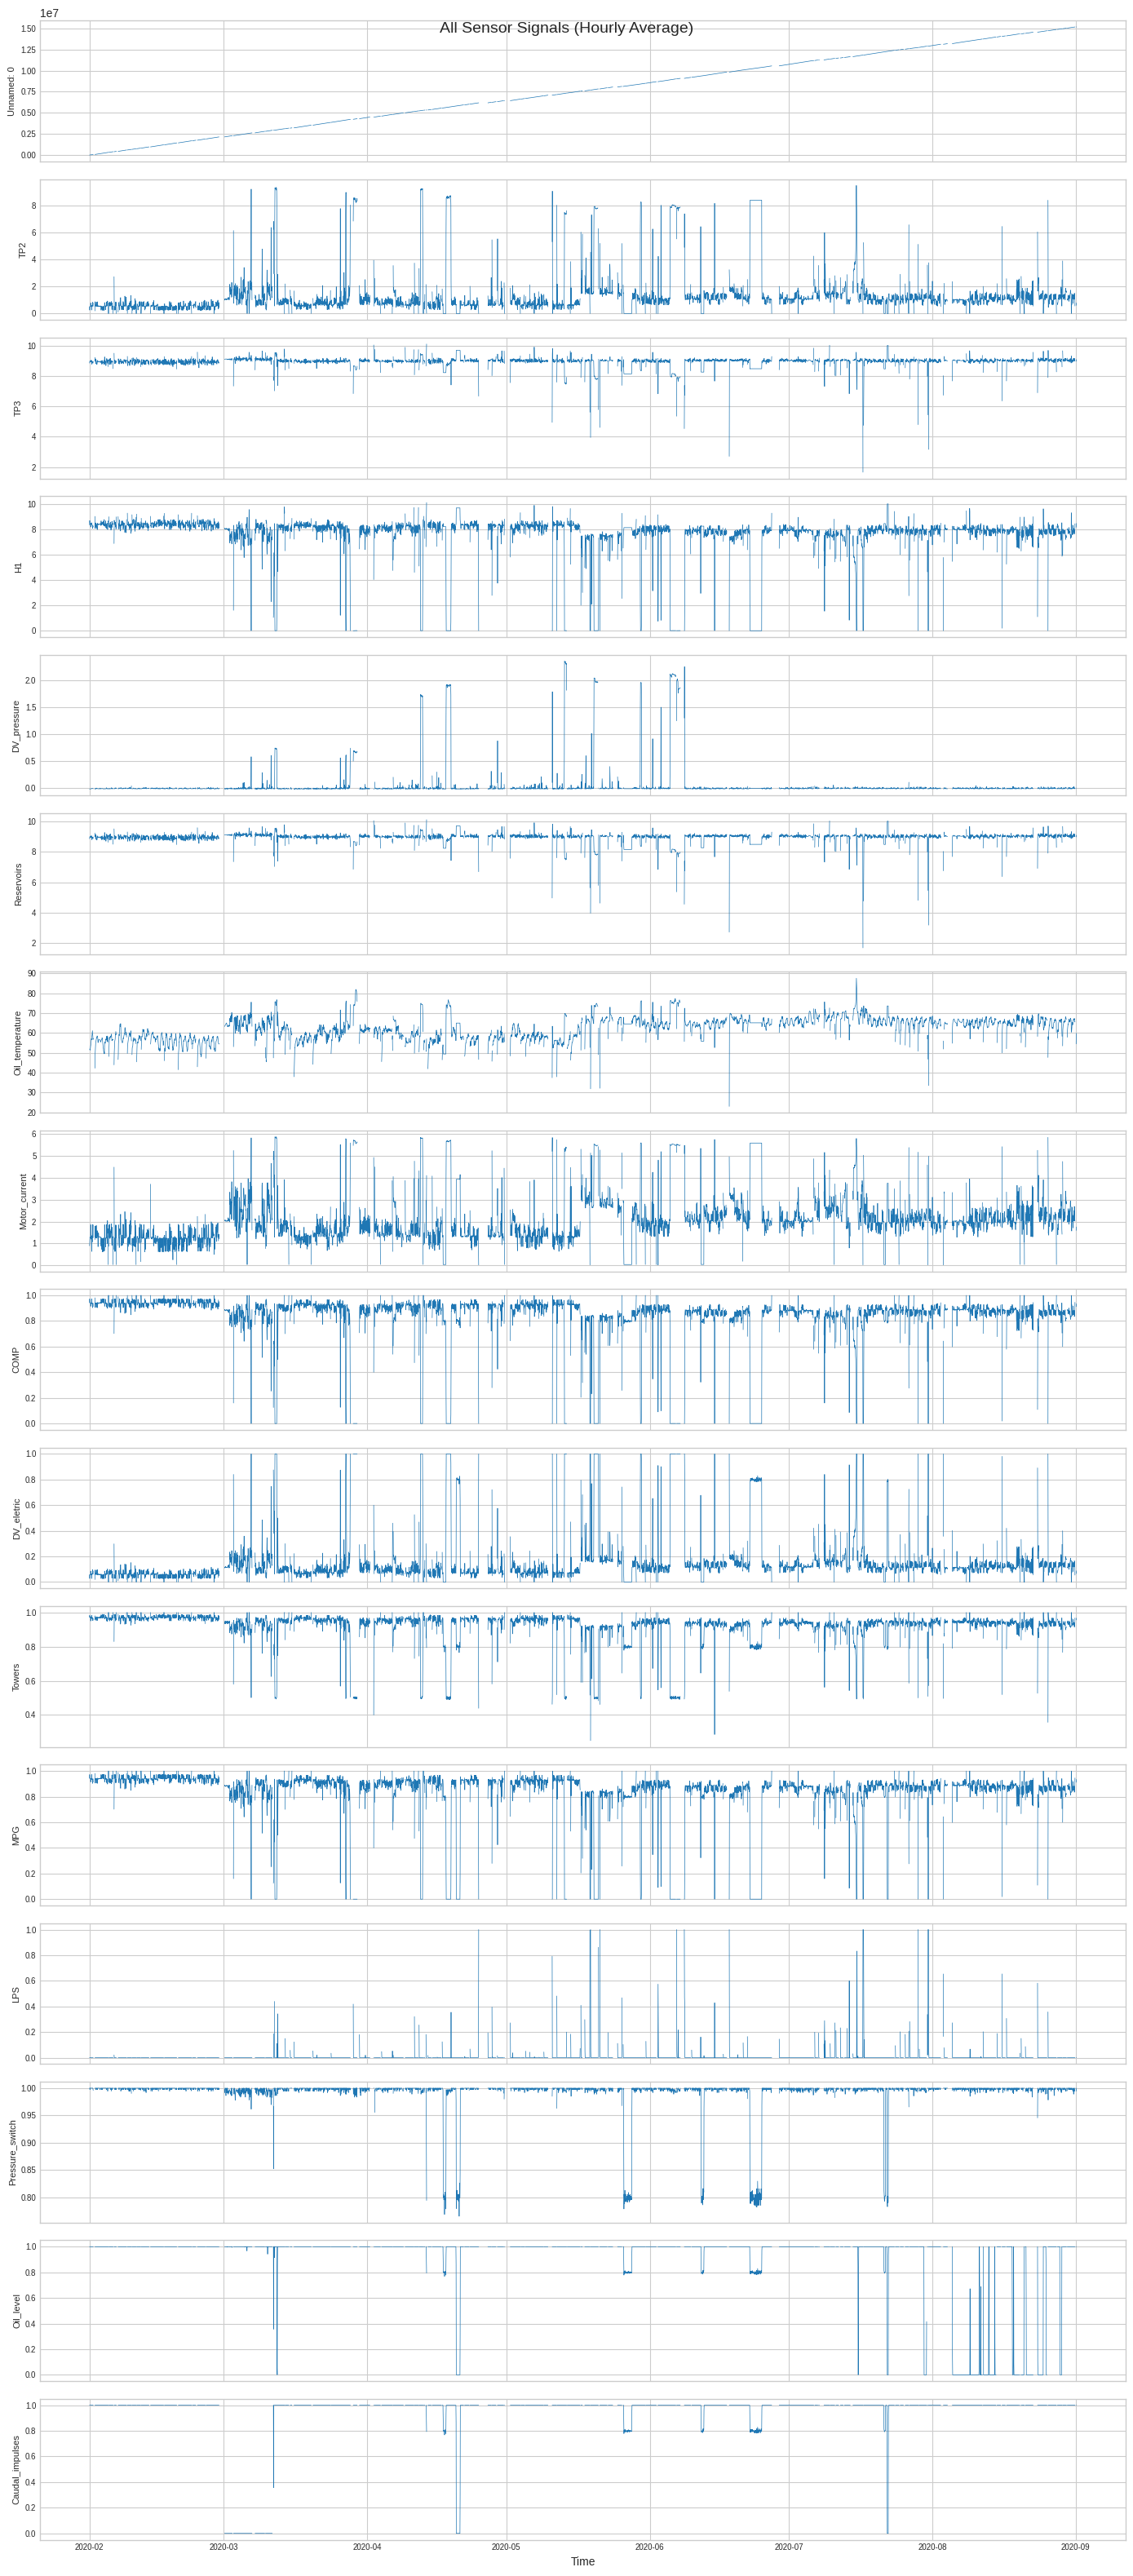

In [10]:
# Plot all signals overview (downsampled for performance)
sample = df.resample('1H').mean()  # Hourly average for overview

fig, axes = plt.subplots(len(sample.columns), 1, figsize=(14, 2*len(sample.columns)), sharex=True)

for idx, col in enumerate(sample.columns):
    axes[idx].plot(sample.index, sample[col], linewidth=0.5)
    axes[idx].set_ylabel(col, fontsize=8)
    axes[idx].tick_params(labelsize=7)

plt.xlabel('Time')
plt.suptitle('All Sensor Signals (Hourly Average)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Identify Failure Periods

According to MetroPT-3 documentation, failure events are documented in maintenance records.

In [11]:
# Known failure periods from MetroPT-3 documentation
# Source: Data Description_Metro.pdf

FAILURE_PERIODS = [
    # (start, end, failure_type, severity)
    ("2020-04-18 00:00:00", "2020-04-18 23:59:00", "Air Leak", "High stress"),
    ("2020-05-29 23:30:00", "2020-05-30 06:00:00", "Air Leak", "High stress"),
    ("2020-06-05 10:00:00", "2020-06-07 14:30:00", "Air Leak", "High stress"),
    ("2020-07-15 14:30:00", "2020-07-15 19:00:00", "Air Leak", "High stress"),
]

# Convert to DataFrame for easier handling
failure_df = pd.DataFrame(FAILURE_PERIODS, columns=['start', 'end', 'failure_type', 'severity'])
failure_df['start'] = pd.to_datetime(failure_df['start'])
failure_df['end'] = pd.to_datetime(failure_df['end'])
failure_df['duration'] = failure_df['end'] - failure_df['start']

print("Documented Failure Periods:")
print("="*70)
for i, row in failure_df.iterrows():
    print(f"Failure #{i+1}: {row['start']} to {row['end']}")
    print(f"           Duration: {row['duration']}, Type: {row['failure_type']}")
    print()

failure_df

Documented Failure Periods:
Failure #1: 2020-04-18 00:00:00 to 2020-04-18 23:59:00
           Duration: 0 days 23:59:00, Type: Air Leak

Failure #2: 2020-05-29 23:30:00 to 2020-05-30 06:00:00
           Duration: 0 days 06:30:00, Type: Air Leak

Failure #3: 2020-06-05 10:00:00 to 2020-06-07 14:30:00
           Duration: 2 days 04:30:00, Type: Air Leak

Failure #4: 2020-07-15 14:30:00 to 2020-07-15 19:00:00
           Duration: 0 days 04:30:00, Type: Air Leak



,start,end,failure_type,severity,duration
0,2020-04-18 00:00:00,2020-04-18 23:59:00,Air Leak,High stress,0 days 23:59:00
1,2020-05-29 23:30:00,2020-05-30 06:00:00,Air Leak,High stress,0 days 06:30:00
2,2020-06-05 10:00:00,2020-06-07 14:30:00,Air Leak,High stress,2 days 04:30:00
3,2020-07-15 14:30:00,2020-07-15 19:00:00,Air Leak,High stress,0 days 04:30:00


/tmp/ipykernel_29383/2095086190.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  plot_df = df.resample('1H').mean()


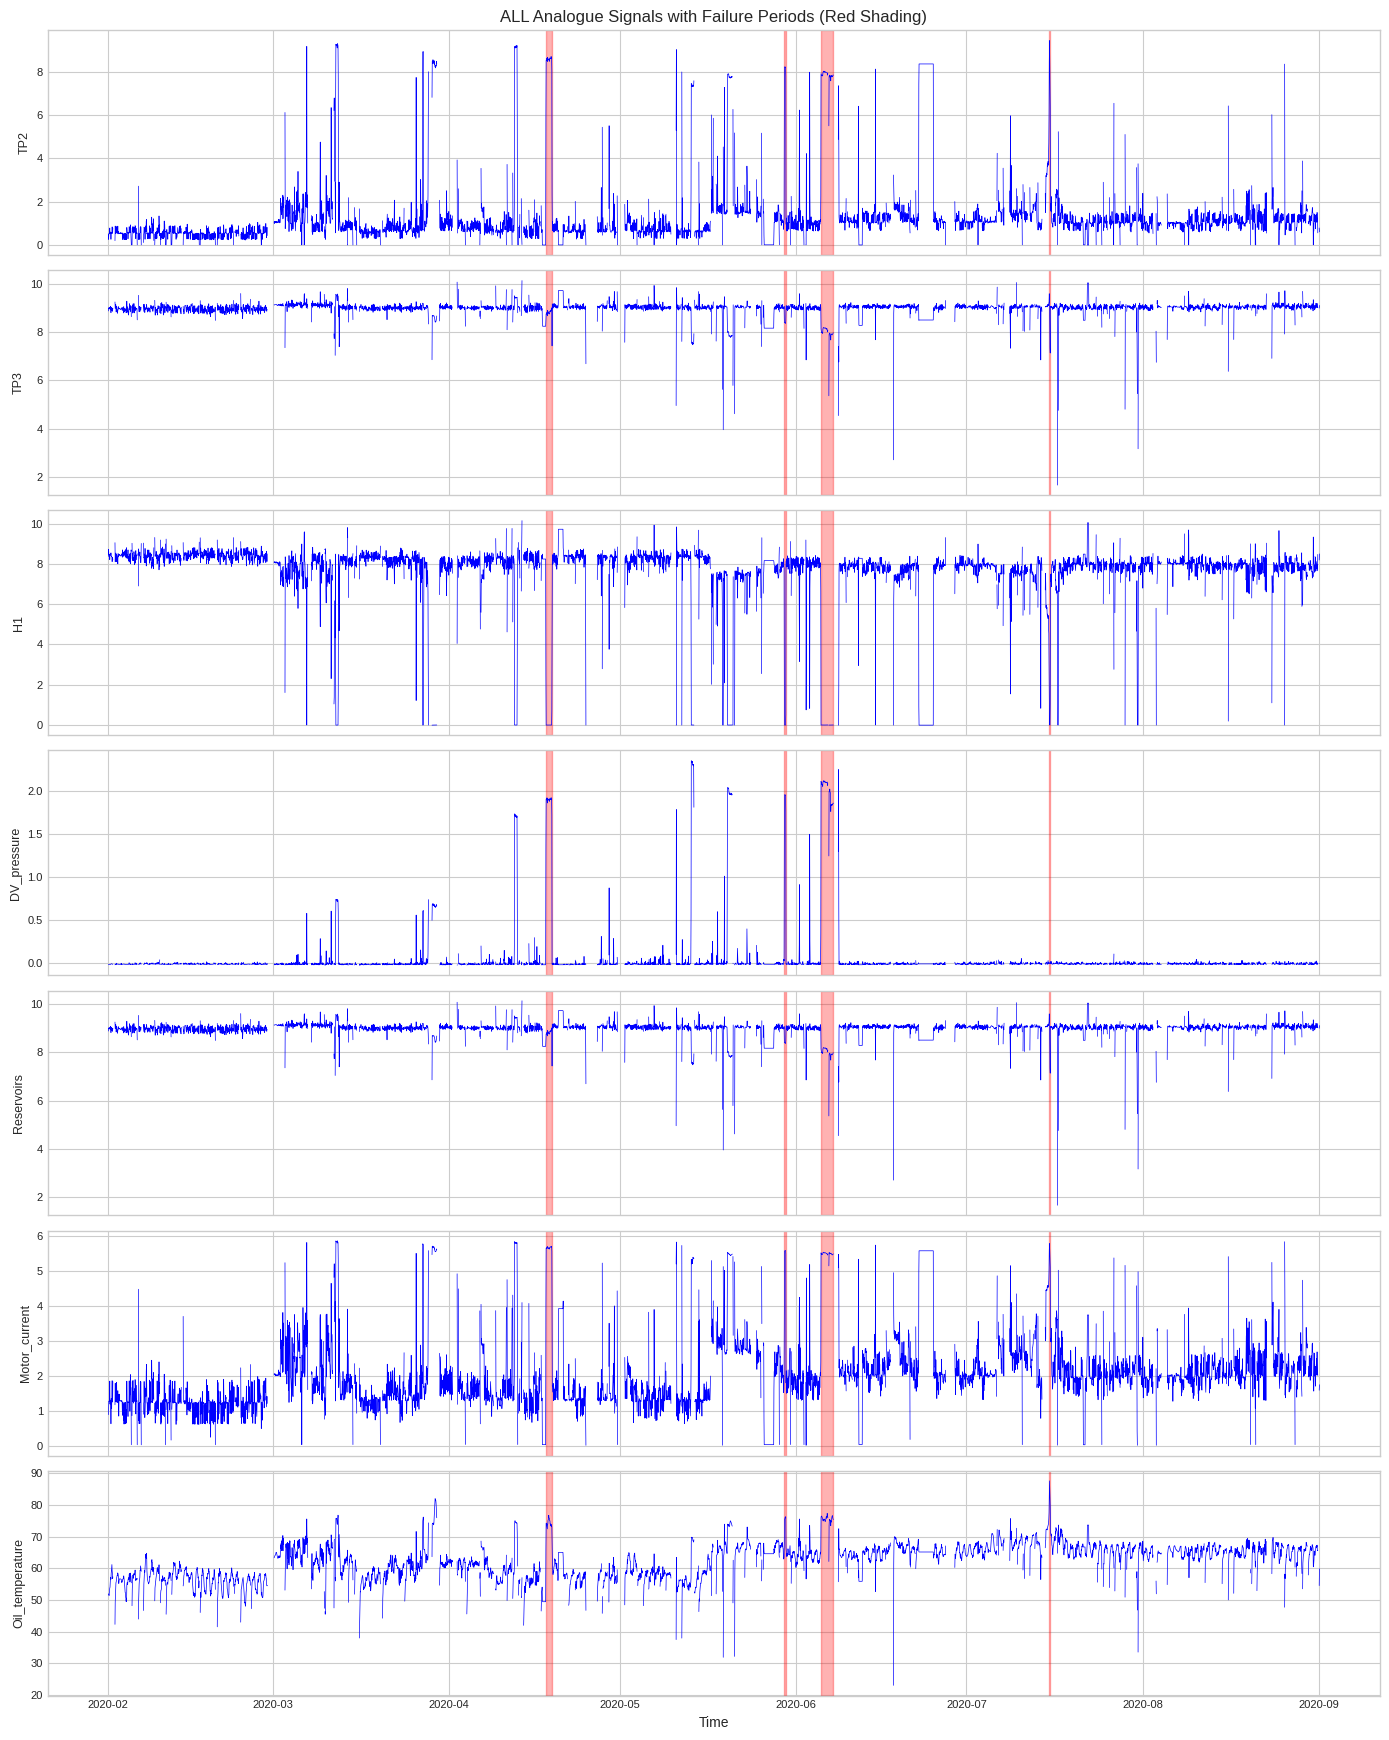

Red shaded areas = documented failure periods
Look for patterns/anomalies BEFORE these periods - those are predictive signals


In [12]:
# Visualize ALL analogue signals with failure periods
# We examine ALL signals - don't assume which ones are important

ANALOGUE_SIGNALS = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Motor_current', 'Oil_temperature']

fig, axes = plt.subplots(len(ANALOGUE_SIGNALS), 1, figsize=(14, 2.5*len(ANALOGUE_SIGNALS)), sharex=True)

# Resample for plotting
plot_df = df.resample('1H').mean()

for ax, signal in zip(axes, ANALOGUE_SIGNALS):
    ax.plot(plot_df.index, plot_df[signal], linewidth=0.5, color='blue')
    
    # Highlight failure periods in red
    for i, row in failure_df.iterrows():
        ax.axvspan(row['start'], row['end'], alpha=0.3, color='red')
    
    ax.set_ylabel(signal, fontsize=9)
    ax.tick_params(labelsize=8)

axes[0].set_title('ALL Analogue Signals with Failure Periods (Red Shading)', fontsize=12)
axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()

print("Red shaded areas = documented failure periods")
print("Look for patterns/anomalies BEFORE these periods - those are predictive signals")

/tmp/ipykernel_29383/4269690713.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  plot_df = df.resample('1H').mean()


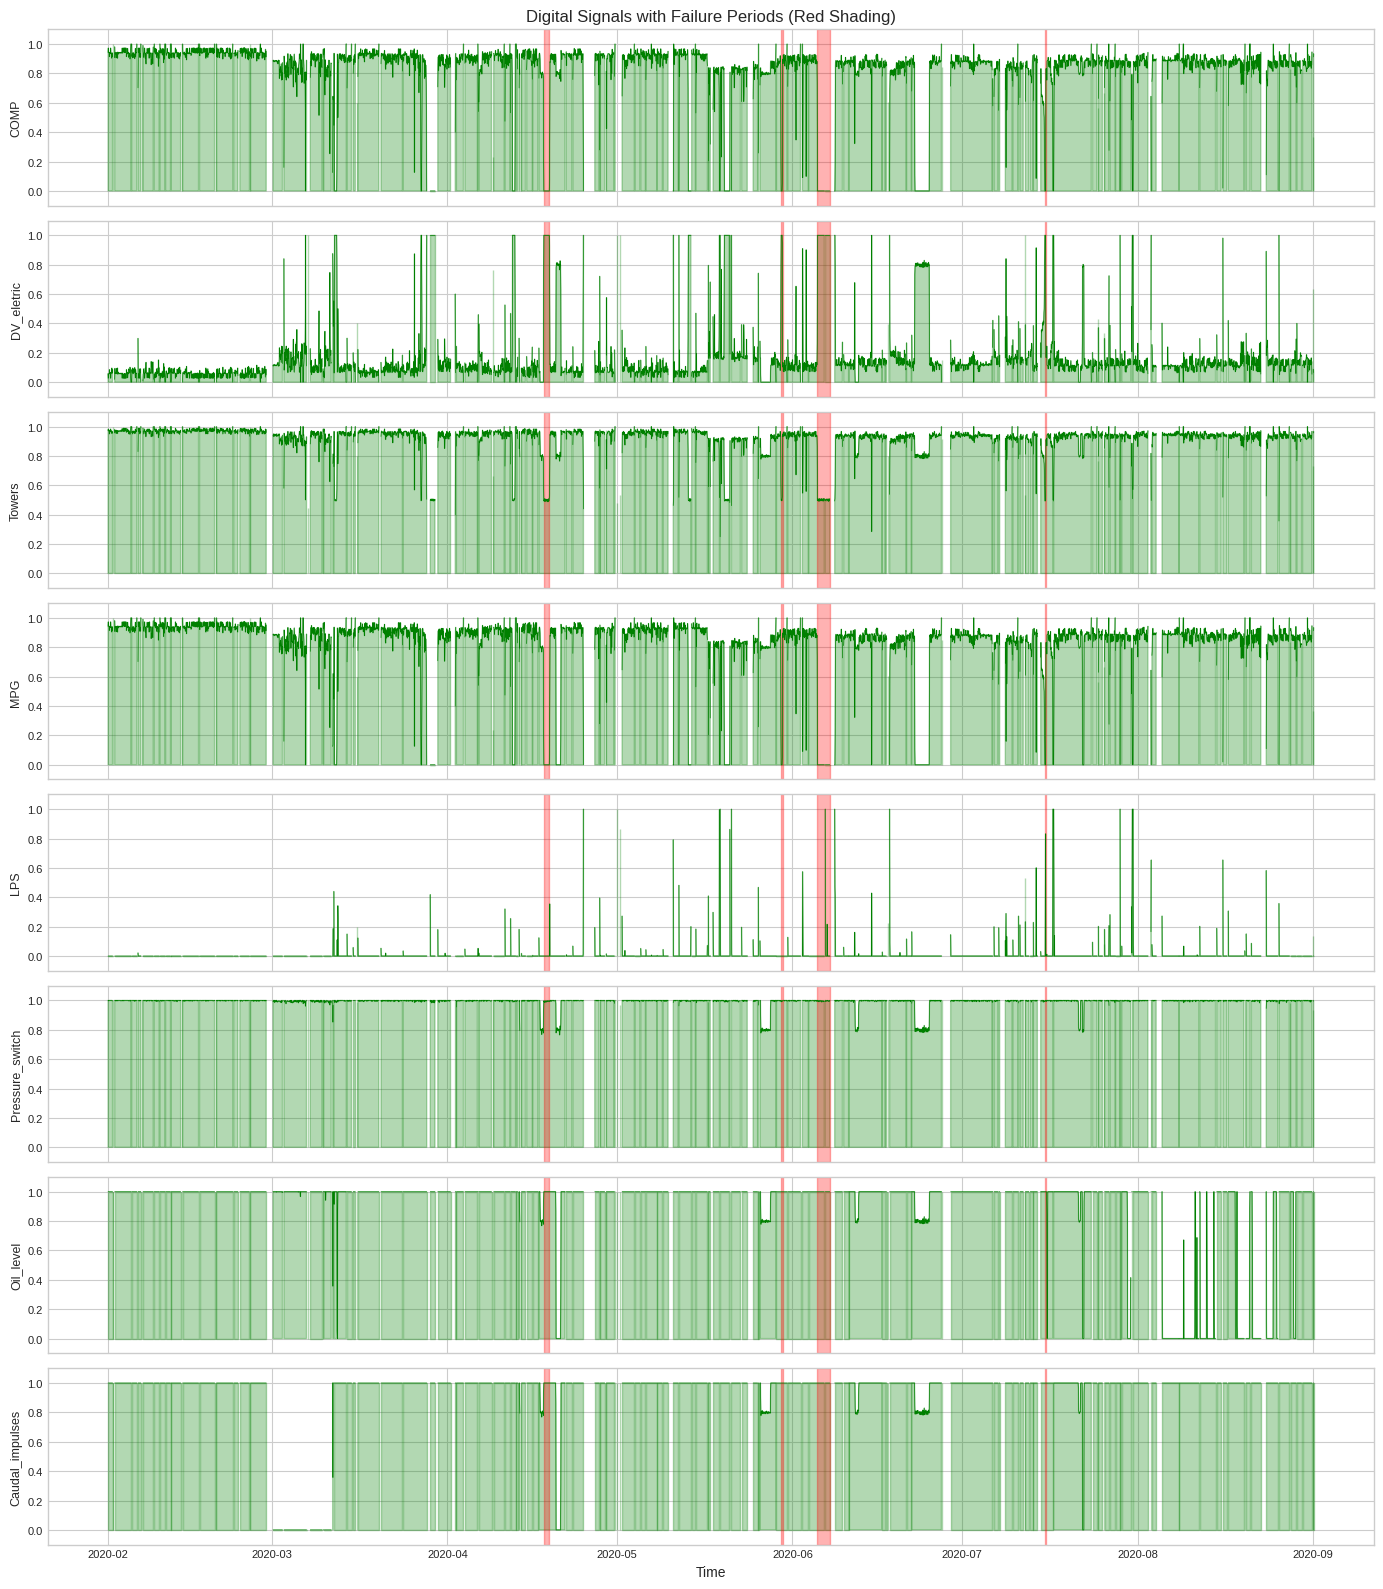

Digital signals show fraction of time active (0=off, 1=on)
Look for unusual activation patterns before failures


In [13]:
# Visualize DIGITAL signals with failure periods
# Digital signals show compressor states - may indicate stress before failure

DIGITAL_SIGNALS = ['COMP', 'DV_eletric', 'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level', 'Caudal_impulses']

fig, axes = plt.subplots(len(DIGITAL_SIGNALS), 1, figsize=(14, 2*len(DIGITAL_SIGNALS)), sharex=True)

# Resample - for digital signals, use mean (shows % of time active)
plot_df = df.resample('1H').mean()

for ax, signal in zip(axes, DIGITAL_SIGNALS):
    ax.plot(plot_df.index, plot_df[signal], linewidth=0.5, color='green')
    ax.fill_between(plot_df.index, 0, plot_df[signal], alpha=0.3, color='green')
    
    # Highlight failure periods
    for i, row in failure_df.iterrows():
        ax.axvspan(row['start'], row['end'], alpha=0.3, color='red')
    
    ax.set_ylabel(signal, fontsize=9)
    ax.set_ylim(-0.1, 1.1)
    ax.tick_params(labelsize=8)

axes[0].set_title('Digital Signals with Failure Periods (Red Shading)', fontsize=12)
axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()

print("Digital signals show fraction of time active (0=off, 1=on)")
print("Look for unusual activation patterns before failures")

## 6. Correlation Analysis

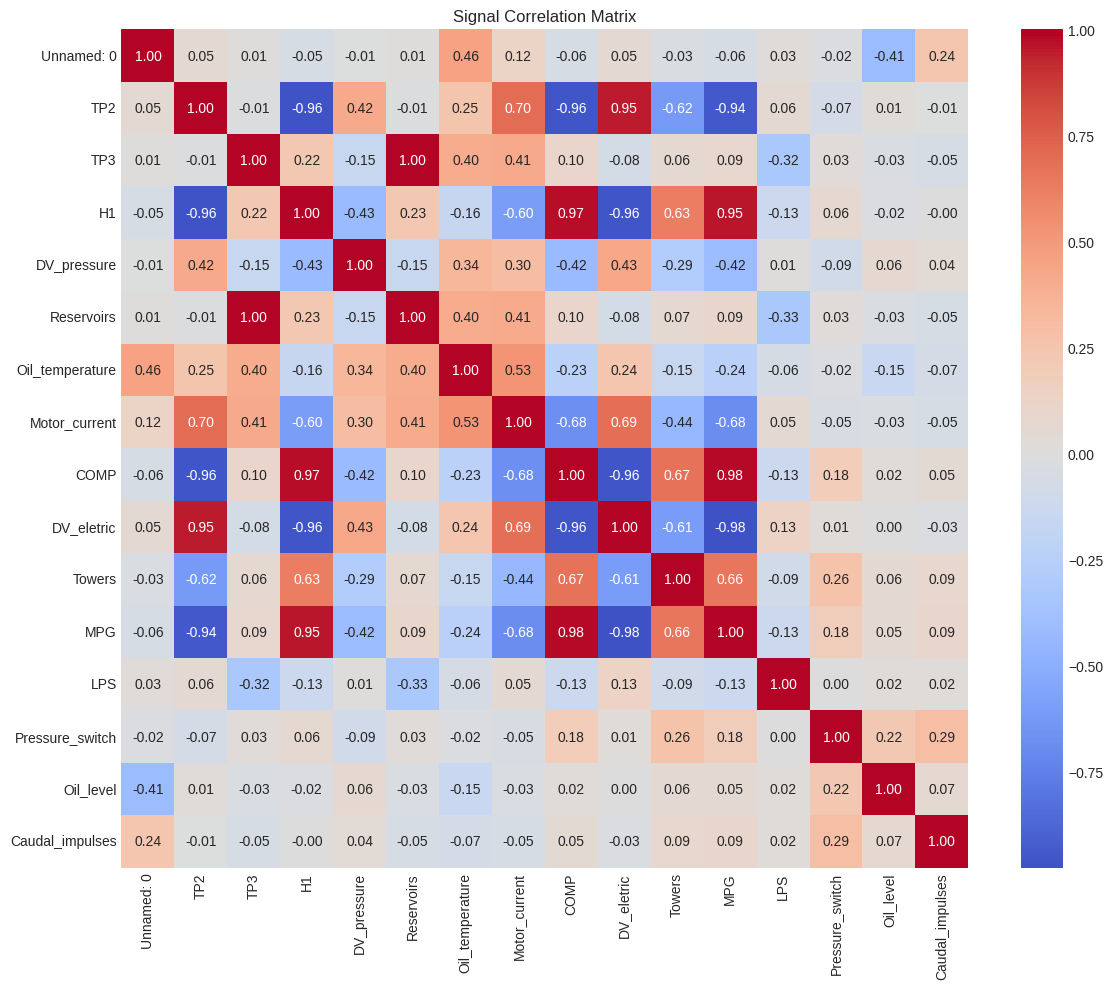

In [14]:
# Correlation matrix
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Signal Correlation Matrix')
plt.tight_layout()
plt.show()

In [16]:
# Quantify signal changes during failures vs normal operation
ANALOGUE = ['TP2', 'TP3', 'H1', 'DV_pressure', 'Reservoirs', 'Motor_current', 'Oil_temperature']

print("SIGNAL BEHAVIOR DURING FAILURES vs NORMAL")
print("="*70)

results = []
for i, row in failure_df.iterrows():
    failure_data = df[row['start']:row['end']]
    normal_before = df[row['start'] - pd.Timedelta(days=7):row['start'] - pd.Timedelta(hours=1)]
    
    print(f"\nFailure #{i+1} ({row['start'].date()}):")
    for col in ANALOGUE:
        fail_mean = failure_data[col].mean()
        norm_mean = normal_before[col].mean() if len(normal_before) > 0 else 0
        diff_pct = ((fail_mean - norm_mean) / abs(norm_mean) * 100) if norm_mean != 0 else 0
        
        if abs(diff_pct) > 10:
            print(f"  {col:20}: {diff_pct:+7.1f}% (normal: {norm_mean:.2f} -> failure: {fail_mean:.2f})")
            results.append({'failure': i+1, 'signal': col, 'change_pct': diff_pct})

SIGNAL BEHAVIOR DURING FAILURES vs NORMAL

Failure #1 (2020-04-18):
  TP2                 :  +476.6% (normal: 1.48 -> failure: 8.52)
  H1                  :   -98.9% (normal: 7.44 -> failure: 0.08)
  DV_pressure         : +1156.2% (normal: 0.15 -> failure: 1.88)
  Motor_current       :  +219.0% (normal: 1.76 -> failure: 5.60)
  Oil_temperature     :   +28.7% (normal: 57.60 -> failure: 74.13)

Failure #2 (2020-05-29):
  TP2                 :  +684.9% (normal: 1.04 -> failure: 8.18)
  H1                  :   -99.1% (normal: 7.72 -> failure: 0.07)
  DV_pressure         : +42552.5% (normal: -0.00 -> failure: 1.92)
  Motor_current       :  +207.6% (normal: 1.81 -> failure: 5.57)
  Oil_temperature     :   +14.4% (normal: 66.32 -> failure: 75.87)

Failure #3 (2020-06-05):
  TP2                 :  +458.6% (normal: 1.41 -> failure: 7.89)
  TP3                 :   -10.7% (normal: 8.98 -> failure: 8.02)
  H1                  :  -100.1% (normal: 7.49 -> failure: -0.01)
  DV_pressure         : +204

In [17]:
# Check LPS (Low Pressure Signal) - rare but important
print("LPS (Low Pressure Signal) ANALYSIS")
print("="*70)
print(f"Overall LPS activation: {df['LPS'].mean()*100:.3f}% of time")
print(f"Total LPS records: {(df['LPS']==1).sum():,} out of {len(df):,}")

print("\nLPS activations around failure periods:")
for i, row in failure_df.iterrows():
    # Check 24h before and during failure
    window_start = row['start'] - pd.Timedelta(hours=24)
    window = df[window_start:row['end']]
    lps_count = (window['LPS'] == 1).sum()
    lps_pct = lps_count / len(window) * 100 if len(window) > 0 else 0
    print(f"  Failure #{i+1}: {lps_count:,} LPS activations ({lps_pct:.2f}%)")

# This shows LPS is a strong indicator for some failures!

LPS (Low Pressure Signal) ANALYSIS
Overall LPS activation: 0.342% of time
Total LPS records: 5,188 out of 1,516,948

LPS activations around failure periods:
  Failure #1: 16 LPS activations (0.11%)
  Failure #2: 0 LPS activations (0.00%)
  Failure #3: 198 LPS activations (0.76%)
  Failure #4: 536 LPS activations (6.87%)


## 8. Summary & Findings

### Dataset Overview
- **Records:** 1,516,948 (sampled at ~10 second intervals, not 1Hz as documented)
- **Time range:** Feb 1, 2020 to Sep 1, 2020 (213 days)
- **Missing values:** None
- **Failures documented:** 4 (all Air Leaks)

### Key Signal Behaviors During Failures

| Signal | During Failure | Interpretation |
|--------|----------------|----------------|
| **TP2** | +374% to +685% | Compressor pressure spikes dramatically |
| **H1** | -97% to -100% | Filter pressure drops to near zero |
| **Motor_current** | +97% to +219% | Motor working much harder |
| **Oil_temperature** | +14% to +29% | Compressor overheating |
| **DV_pressure** | Extreme changes | Air dryer pressure unstable |

### Signal Correlations
- **TP2 ↔ H1:** 0.96 (very high) - both pressure measurements
- **TP3 ↔ Reservoirs:** 1.00 (perfect) - essentially same measurement
- **Motor_current ↔ TP2:** 0.70 - motor works harder when pressure builds
- **Oil_temperature ↔ Motor_current:** 0.53 - heat from motor load

### Digital Signal Insights
- **LPS (Low Pressure):** Only 0.34% active overall, but spikes during failures #3 and #4
  - Failure #3: 198 LPS activations
  - Failure #4: 536 LPS activations
- **Oil_level warnings:** 9.58% of time (potential noise or real concern)

### Pre-Failure Patterns (Early Warning Signs)
- **Oil_temperature:** Elevated 1.7 std above normal 6 hours before Failure #4
- **LPS activations:** Increase in hours before failures #3 and #4

### Implications for Modeling

**Strong failure indicators (for anomaly detection):**
1. TP2 sudden spike
2. H1 dropping to near zero
3. Motor_current surge
4. LPS activations (rare event)

**Potential early warning signals (for prediction):**
1. Oil_temperature gradual rise
2. Increasing LPS activation frequency
3. TP2/H1 ratio changes

### Next Steps
1. Create failure labels (pre-failure windows)
2. Feature engineering (rolling statistics)
3. Proceed to `02_preprocessing.ipynb`

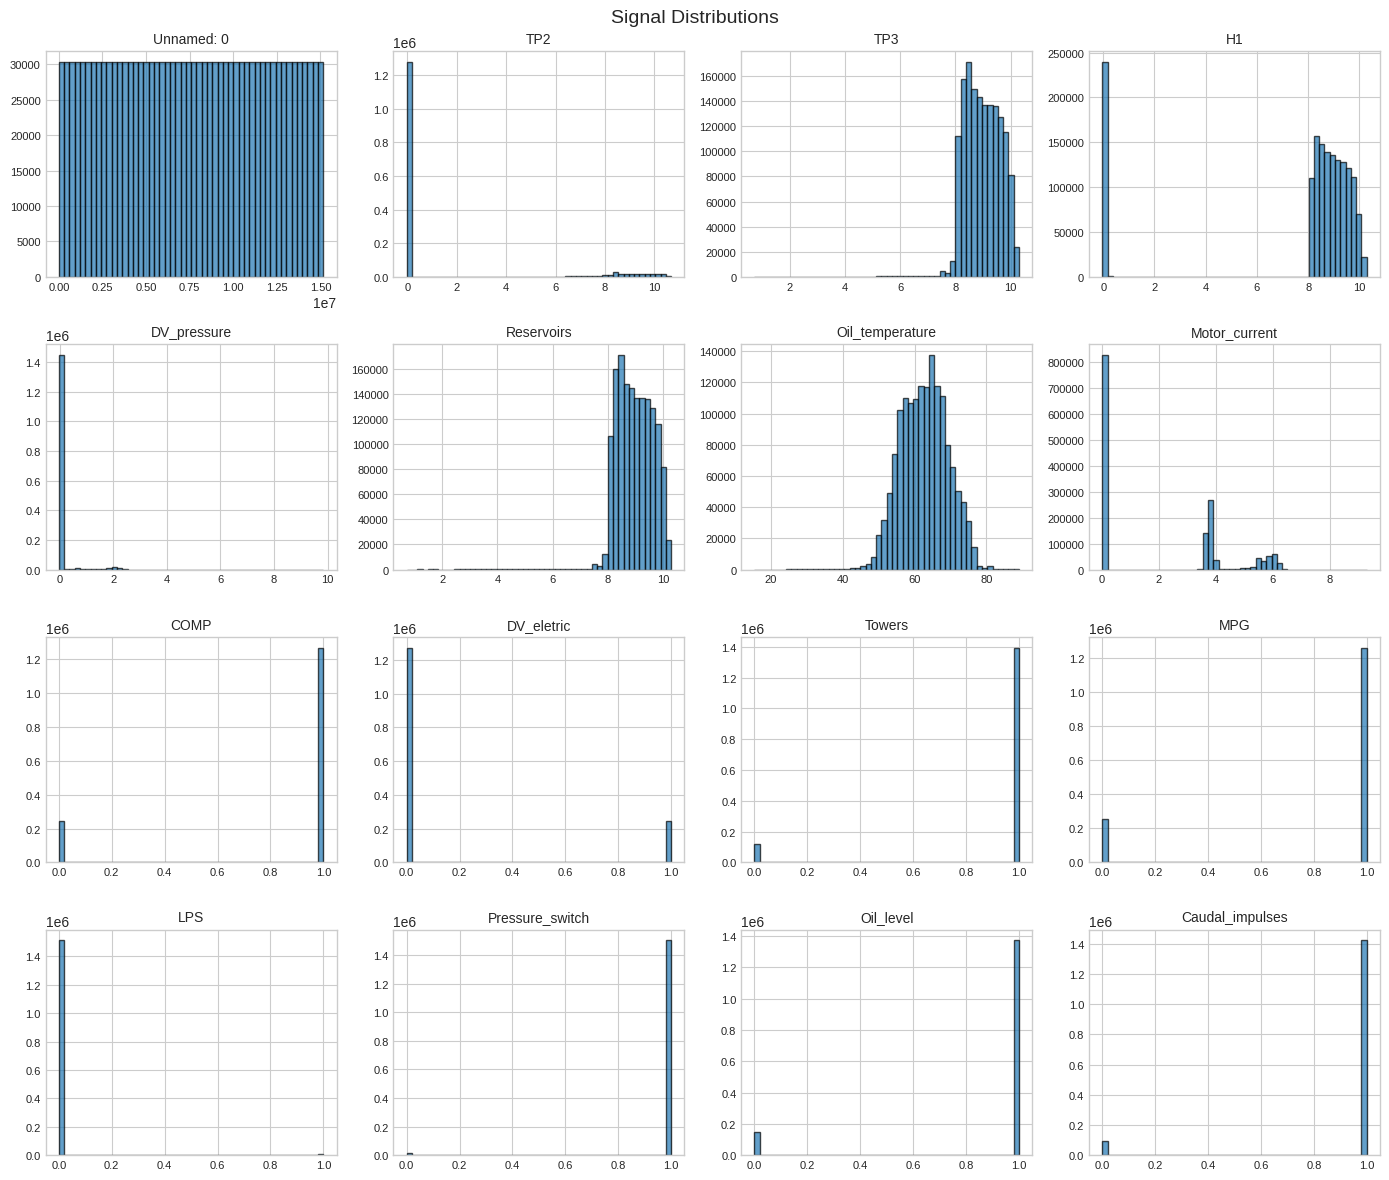

In [18]:
# Histograms of all signals
fig, axes = plt.subplots(4, 4, figsize=(14, 12))
axes = axes.flatten()

for idx, col in enumerate(df.columns):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
        axes[idx].set_title(col, fontsize=10)
        axes[idx].tick_params(labelsize=8)

# Hide unused subplots
for idx in range(len(df.columns), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Signal Distributions', fontsize=14)
plt.tight_layout()
plt.show()